ШАГ 0

In [2]:
!pip install -q emotiefflib
!pip install -q transformers>=4.38.0
!pip install -q faster-whisper
!pip install -q insightface
!pip install -q opencv-python-headless
!pip install -q librosa soundfile scikit-learn

import torch

if torch.cuda.is_available():
    !pip install -q onnxruntime-gpu
else:
    !pip install -q onnxruntime

!pip install -q torchvision

print(f"PyTorch: {torch.__version__}")
print(f"CUDA: {torch.cuda.is_available()}")
if torch.cuda.is_available():
    print(f"GPU: {torch.cuda.get_device_name(0)}")

PyTorch: 2.10.0+cu128
CUDA: True
GPU: NVIDIA RTX PRO 6000 Blackwell Server Edition


ШАГ 1

In [3]:
from google.colab import drive
drive.mount('/content/drive')

import os
DATA_ROOT  = "/content/drive/MyDrive/DVD_Database"
OUTPUT_DIR = "/content/drive/MyDrive/DVD_outputs"
FEAT_DIR   = os.path.join(OUTPUT_DIR, "features")
CKPT_DIR   = os.path.join(OUTPUT_DIR, "checkpoints")

for d in [OUTPUT_DIR, FEAT_DIR, CKPT_DIR]:
    os.makedirs(d, exist_ok=True)

print("DATA_ROOT :", DATA_ROOT)
print("Файлы найдены:", os.path.exists(DATA_ROOT))

for split in ['Training', 'Validation']:
    vd = os.path.join(DATA_ROOT, split, 'videos')
    ad = os.path.join(DATA_ROOT, split, 'annotations')
    nv = len(os.listdir(vd)) if os.path.exists(vd) else 0
    na = len(os.listdir(ad)) if os.path.exists(ad) else 0
    print(f"  {split}: {nv} видео, {na} аннотаций")


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
DATA_ROOT : /content/drive/MyDrive/DVD_Database
Файлы найдены: True
  Training: 103 видео, 103 аннотаций
  Validation: 17 видео, 17 аннотаций


ШАГ 2 - Импорты и глобальные настройки

In [25]:
import os, gc, warnings, json, time
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
from pathlib import Path
from tqdm import tqdm
from scipy.signal import medfilt

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader, WeightedRandomSampler
from torch.optim import AdamW
from torch.optim.lr_scheduler import CosineAnnealingLR
from sklearn.metrics import f1_score

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"

# Гиперпараметры
BATCH_SIZE      = 256
WINDOW_SIZE     = 64
HOP_SIZE        = 32
EPOCHS          = 40
LR              = 1e-4
WEIGHT_DECAY    = 1e-4
MODAL_DROPOUT_P = 0.20
SMOOTH_KERNEL   = 15

# Размерности признаков — обновлены под текущий пайплайн
VIS_FEAT_DIM = 512    # EmotiEffLib mbf_va_mtl embedding
VIS_SCR_DIM  = 10     # emotion logits
GLOBAL_DIM   = 768    # ConvNeXt-T
VIS_DIM      = VIS_FEAT_DIM + VIS_SCR_DIM + GLOBAL_DIM  # 1290
AUD_DIM      = 1024   # HuBERT-large
TXT_DIM      = 768    # RoBERTa-base

print(f"Device: {DEVICE} | Window: {WINDOW_SIZE} | Batch: {BATCH_SIZE}")
print(f"VIS_DIM={VIS_DIM} | AUD_DIM={AUD_DIM} | TXT_DIM={TXT_DIM}")

Device: cuda | Window: 64 | Batch: 256
VIS_DIM=1290 | AUD_DIM=1024 | TXT_DIM=768


ШАГ 3 - Утилиты загрузки данных

In [26]:
import subprocess, json

_audio_cache = {}

def has_audio_stream(video_path, timeout=120):
    if video_path in _audio_cache:
        return _audio_cache[video_path]

    try:
        result = subprocess.run(
            ['ffprobe', '-v', 'quiet',
             '-print_format', 'json',
             '-show_streams', video_path],
            capture_output=True, text=True, timeout=timeout
        )
        streams = json.loads(result.stdout).get('streams', [])
        has_audio = any(s.get('codec_type') == 'audio' for s in streams)
    except Exception:
        has_audio = False

    _audio_cache[video_path] = has_audio
    return has_audio


def load_annotations(ann_path):
    df = pd.read_csv(ann_path)
    df.columns = [c.strip() for c in df.columns]
    if 'Frame_Number' in df.columns:
        df = df.rename(columns={'Frame_Number': 'frame', 'Label': 'label'})
    return df[df['label'] != -1].reset_index(drop=True)


def get_video_list(split):
    video_dir = Path(DATA_ROOT) / split / "videos"
    ann_dir   = Path(DATA_ROOT) / split / "annotations"
    pairs = []
    for vp in sorted(video_dir.glob("*.mp4")):
        ap = ann_dir / (vp.stem + ".csv")
        if ap.exists():
            pairs.append((str(vp), str(ap)))
    return pairs


def get_fps(video_path):
    import cv2
    cap = cv2.VideoCapture(video_path)
    fps = cap.get(cv2.CAP_PROP_FPS)
    cap.release()
    return fps if fps > 0 else 25.0


def compute_macro_f1(y_true, y_pred):
    return f1_score(y_true, y_pred, average='macro', labels=[0, 1],
                    zero_division=0)

print("Утилиты загружены.")
for split in ['Training', 'Validation']:
    pairs = get_video_list(split)
    print(f"  {split}: {len(pairs)} видео")

Утилиты загружены.
  Training: 102 видео
  Validation: 17 видео


ШАГ 4 - Копирование видео локально

In [27]:
import shutil, os
from pathlib import Path

DRIVE_ROOT = "/content/drive/MyDrive/DVD_Database"
LOCAL_ROOT = "/content/DVD_Database"

cache_files = list(Path(FEAT_DIR).glob("Training_*.npz"))
print(f"Файлов в кэше: {len(cache_files)}")

def copy_to_local(split):
    src_vid = Path(DRIVE_ROOT) / split / "videos"
    src_ann = Path(DRIVE_ROOT) / split / "annotations"
    dst_vid = Path(LOCAL_ROOT) / split / "videos"
    dst_ann = Path(LOCAL_ROOT) / split / "annotations"
    dst_vid.mkdir(parents=True, exist_ok=True)
    dst_ann.mkdir(parents=True, exist_ok=True)

    videos = list(src_vid.glob("*.mp4"))
    print(f"[{split}] Копирую {len(videos)} видео...")
    for vp in tqdm(videos, desc=f"Copy {split}"):
        dst = dst_vid / vp.name
        if not dst.exists():
            shutil.copy2(str(vp), str(dst))

    for ap in src_ann.glob("*.csv"):
        dst = dst_ann / ap.name
        if not dst.exists():
            shutil.copy2(str(ap), str(dst))
    print(f"[{split}] Готово.")

local_videos = list(Path(LOCAL_ROOT).glob("Training/videos/*.mp4"))
if len(local_videos) < 100:
    print("Копирую видео локально...")
    copy_to_local('Training')
    copy_to_local('Validation')
else:
    print(f"Видео уже скопированы ({len(local_videos)} файлов)")

DATA_ROOT = LOCAL_ROOT
_audio_cache.clear()
print(f"\nDATA_ROOT → {DATA_ROOT}")

for split in ['Training', 'Validation']:
    pairs = get_video_list(split)
    print(f"  {split}: {len(pairs)} видео")

Файлов в кэше: 102
Видео уже скопированы (102 файлов)

DATA_ROOT → /content/DVD_Database
  Training: 102 видео
  Validation: 17 видео


ШАГ 5 - EmotiEffLib

In [16]:
import cv2, torch, numpy as np, subprocess, tempfile, os, time
from pathlib import Path
from emotiefflib.facial_analysis import EmotiEffLibRecognizer

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Device: {DEVICE}")

print("Загружаю EmotiEffLib (mbf_va_mtl)...")
_recognizer = EmotiEffLibRecognizer(engine='torch', model_name='mbf_va_mtl', device=DEVICE)
print("EmotiEffLib загружен.")

VIS_FEAT_DIM  = 512
VIS_SCR_DIM   = 10
VIS_DIM       = 522
VISUAL_STRIDE = 5
BATCH         = 64

def decode_video_ffmpeg(video_path, frame_ids, fps=25.0):
    """Декодирует кадры через ffmpeg, разбивая длинные видео на чанки."""
    if not frame_ids:
        return {}

    needed  = sorted(frame_ids)
    results = {}

    # Разбиение на чанки по 500 кадров
    CHUNK_FRAMES = 500
    for chunk_start in range(0, len(needed), CHUNK_FRAMES):
        chunk_fids = needed[chunk_start: chunk_start + CHUNK_FRAMES]
        min_fid    = chunk_fids[0]
        max_fid    = chunk_fids[-1]
        start_t    = max(0.0, (min_fid - 1) / fps)
        dur_t      = (max_fid - min_fid + 2) / fps

        with tempfile.TemporaryDirectory() as tmpdir:
            out_pattern = os.path.join(tmpdir, 'f%06d.jpg')
            result = subprocess.run(
                ['ffmpeg', '-y',
                 '-ss', f'{start_t:.3f}',
                 '-i', video_path,
                 '-t', f'{dur_t:.3f}',
                 '-vf', f'fps={fps},scale=224:224',
                 '-q:v', '3',
                 out_pattern, '-loglevel', 'error'],
                capture_output=True, timeout=600)

            if result.returncode != 0:
                continue

            jpg_files = sorted(os.listdir(tmpdir))
            chunk_set = set(chunk_fids)

            for i, fname in enumerate(jpg_files):
                fid = min_fid + i
                # Поиск ближайшего нужного frame_id
                if chunk_set:
                    closest = min(chunk_set, key=lambda x: abs(x - fid))
                    if abs(closest - fid) <= VISUAL_STRIDE + 1:
                        img = cv2.imread(os.path.join(tmpdir, fname))
                        if img is not None and closest not in results:
                            results[closest] = img
                            chunk_set.discard(closest)
    return results

def extract_visual_features(video_path, ann_df):
    N        = len(ann_df)
    fps      = get_fps(video_path)
    all_fids = sorted(ann_df['frame'].tolist())

    # Субдискретизация
    stride_fids = all_fids[::VISUAL_STRIDE]
    if all_fids[-1] not in stride_fids:
        stride_fids.append(all_fids[-1])
    stride_fids = sorted(set(stride_fids))

    # Декодирование
    cap     = cv2.VideoCapture(video_path)
    use_cv2 = False
    if cap.isOpened():
        cap.set(cv2.CAP_PROP_POS_FRAMES, stride_fids[0])
        ret, _ = cap.read()
        use_cv2 = ret

    if use_cv2:
        raw_frames = {}
        for fid in stride_fids:
            cap.set(cv2.CAP_PROP_POS_FRAMES, int(fid))
            ret, frame = cap.read()
            if ret and frame is not None:
                raw_frames[fid] = frame
        cap.release()
    else:
        cap.release()
        raw_frames = decode_video_ffmpeg(video_path, stride_fids, fps)

    feat_dict = {}
    scr_dict  = {}

    fid_list = sorted(raw_frames.keys())
    for i in range(0, len(fid_list), BATCH):
        batch_fids   = fid_list[i: i + BATCH]
        batch_frames = [cv2.cvtColor(raw_frames[f], cv2.COLOR_BGR2RGB)
                        for f in batch_fids]
        try:
            embs = np.array(
                _recognizer.extract_features(batch_frames),
                np.float32).reshape(len(batch_fids), -1)
            _, logits = _recognizer.predict_emotions(
                batch_frames, logits=True)
            logits = np.array(logits, np.float32).reshape(
                len(batch_fids), -1)
            for j, fid in enumerate(batch_fids):
                feat_dict[fid] = embs[j,   :VIS_FEAT_DIM]
                scr_dict[fid]  = logits[j, :VIS_SCR_DIM]
        except Exception:
            for fid in batch_fids:
                try:
                    rgb = cv2.cvtColor(raw_frames[fid], cv2.COLOR_BGR2RGB)
                    emb = _recognizer.extract_features(rgb)
                    feat_dict[fid] = np.array(
                        emb, np.float32).flatten()[:VIS_FEAT_DIM]
                    _, lg = _recognizer.predict_emotions(rgb, logits=True)
                    scr_dict[fid] = np.array(
                        lg, np.float32).flatten()[:VIS_SCR_DIM]
                except Exception:
                    pass

    # Заполнение всех кадров методом nearest (без интерполяции scipy)
    vis_full = np.zeros((N, VIS_FEAT_DIM), np.float32)
    scr_full = np.zeros((N, VIS_SCR_DIM),  np.float32)

    if not feat_dict:
        return vis_full, scr_full

    processed = sorted(feat_dict.keys())

    for i, fid in enumerate(all_fids):
        closest = min(processed, key=lambda x: abs(x - fid))
        vis_full[i] = feat_dict[closest]
        scr_full[i] = scr_dict[closest]

    return vis_full.astype(np.float32), scr_full.astype(np.float32)

vp, ap   = get_video_list('Training')[0]
ann_test = load_annotations(ap)
t0 = time.time()
vf, vs = extract_visual_features(vp, ann_test)
dt = time.time() - t0
speed = len(ann_test) / dt
print(f"Время: {dt:.1f}с | Скорость: {speed:.0f} кадров/сек")
print(f"vis={vf.shape} | signal={np.any(vf!=0)}")
print(f"Оценка Training: {770916/speed/3600:.1f} ч")

Device: cuda
Загружаю EmotiEffLib (mbf_va_mtl)...
EmotiEffLib загружен.
Время: 3.1с | Скорость: 597 кадров/сек
vis=(1865, 512) | signal=True
Оценка Training: 0.4 ч


ШАГ 6 - HuBERT аудио

In [17]:
AUDIO_MODEL_NAME = "facebook/hubert-large-ls960-ft"

def extract_audio_waveform(video_path, sr=16000):
    import subprocess, tempfile, soundfile as sf

    with tempfile.NamedTemporaryFile(suffix='.wav', delete=False) as tmp:
        wav_path = tmp.name
    try:
        result = subprocess.run(
            ['ffmpeg', '-y', '-i', video_path,
             '-ac', '1', '-ar', str(sr), '-vn',
             wav_path, '-loglevel', 'error'],
            capture_output=True, timeout=120
        )
        if result.returncode != 0 or not os.path.exists(wav_path):
            return np.zeros(sr, np.float32), False
        audio, _ = sf.read(wav_path)
        audio = audio.astype(np.float32)
        if audio.ndim > 1:
            audio = audio.mean(axis=1)
        return audio, True
    except Exception:
        return np.zeros(sr, np.float32), False
    finally:
        if os.path.exists(wav_path):
            os.unlink(wav_path)

def extract_audio_features(video_path, ann_df, fps=25.0):
    from transformers import AutoFeatureExtractor, AutoModel

    N = len(ann_df)
    H = 1024

    if not hasattr(extract_audio_features, '_model'):
        print(f"  Загружаю {AUDIO_MODEL_NAME}...")
        extract_audio_features._fe = AutoFeatureExtractor.from_pretrained(
            AUDIO_MODEL_NAME)
        extract_audio_features._model = AutoModel.from_pretrained(
            AUDIO_MODEL_NAME).to(DEVICE)
        extract_audio_features._model.eval()
        print("  Готово.")

    fe    = extract_audio_features._fe
    model = extract_audio_features._model

    audio, has_audio = extract_audio_waveform(video_path)
    SR = 16000

    if not has_audio or len(audio) < SR * 0.5:
        return np.zeros((N, H), np.float32)

    # Нарезка на чанки 1 сек с перекрытием 0.5 сек
    chunk_len = SR
    hop_len   = SR // 2
    chunks, tstamps = [], []
    for start in range(0, max(1, len(audio) - chunk_len + 1), hop_len):
        chunk = audio[start: start + chunk_len]
        if len(chunk) < chunk_len:
            chunk = np.pad(chunk, (0, chunk_len - len(chunk)))
        chunks.append(chunk)
        tstamps.append((start + chunk_len / 2) / SR)

    if not chunks:
        return np.zeros((N, H), np.float32)

    embeds = []
    for i in range(0, len(chunks), 32):
        batch  = chunks[i: i + 32]
        inputs = fe(batch, sampling_rate=SR,
                    return_tensors='pt', padding=True).to(DEVICE)
        with torch.no_grad():
            out = model(**inputs)
        embeds.append(out.last_hidden_state.mean(dim=1).cpu().numpy())

    embeds  = np.concatenate(embeds, axis=0)  # [T, 1024]
    tstamps = np.array(tstamps)

    frame_times = np.array(ann_df['frame'].tolist()) / fps
    feat = np.zeros((N, H), np.float32)
    if len(tstamps) == 0:
        pass
    elif len(tstamps) == 1:
        feat[:] = embeds[0]
    else:
        tstamps_arr = np.array(tstamps)
        n_embeds    = len(embeds)
        for i, ft in enumerate(frame_times):
            closest_idx = int(np.argmin(np.abs(tstamps_arr - ft)))
            closest_idx = min(closest_idx, n_embeds - 1)
            feat[i] = embeds[closest_idx]

    return feat.astype(np.float32)

test_pairs = get_video_list('Training')
if test_pairs:
    vp, ap = test_pairs[0]
    ann_test = load_annotations(ap)
    feat_test = extract_audio_features(vp, ann_test, fps=get_fps(vp))
    print(f"✓ shape={feat_test.shape}, has_signal={np.any(feat_test != 0)}")

  Загружаю facebook/hubert-large-ls960-ft...


preprocessor_config.json:   0%|          | 0.00/212 [00:00<?, ?B/s]

config.json: 0.00B [00:00, ?B/s]

pytorch_model.bin:   0%|          | 0.00/1.26G [00:00<?, ?B/s]

Loading weights:   0%|          | 0/422 [00:00<?, ?it/s]

HubertModel LOAD REPORT from: facebook/hubert-large-ls960-ft
Key            | Status     |  | 
---------------+------------+--+-
lm_head.bias   | UNEXPECTED |  | 
lm_head.weight | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


  Готово.
✓ shape=(1865, 1024), has_signal=False


ШАГ 7 - Whisper + RoBERTa

In [18]:
TEXT_MODEL_NAME = "SamLowe/roberta-base-go_emotions"
WHISPER_SIZE    = "small"

def transcribe_video(video_path):
    from faster_whisper import WhisperModel
    import tempfile, subprocess

    if not has_audio_stream(video_path):
        return []

    with tempfile.NamedTemporaryFile(suffix='.wav', delete=False) as tmp:
        wav_path = tmp.name

    try:
        result = subprocess.run(
            ['ffmpeg', '-y', '-i', video_path,
             '-ac', '1', '-ar', '16000', '-vn',
             wav_path, '-loglevel', 'error'],
            capture_output=True, timeout=120
        )
        if result.returncode != 0 or os.path.getsize(wav_path) == 0:
            return []

        if not hasattr(transcribe_video, '_model'):
            print(f"  Загружаю Whisper {WHISPER_SIZE}...")
            transcribe_video._model = WhisperModel(
                WHISPER_SIZE,
                device=DEVICE,
                compute_type="float16" if DEVICE == "cuda" else "int8"
            )
            print("  Whisper готов.")

        segs_iter, _ = transcribe_video._model.transcribe(
            wav_path,
            beam_size=3,
            language=None,
            vad_filter=True
        )
        segs = [
            {'start': s.start, 'end': s.end, 'text': s.text}
            for s in segs_iter
        ]
        return segs

    except Exception as e:
        print(f"  Whisper ошибка: {e}")
        return []
    finally:
        if os.path.exists(wav_path):
            os.unlink(wav_path)

def extract_text_features(video_path, ann_df, fps=25.0):
    from transformers import AutoTokenizer, AutoModel

    N = len(ann_df)
    H = 768

    if not hasattr(extract_text_features, '_model'):
        print(f"  Загружаю {TEXT_MODEL_NAME}...")
        extract_text_features._tok = AutoTokenizer.from_pretrained(
            TEXT_MODEL_NAME
        )
        extract_text_features._model = AutoModel.from_pretrained(
            TEXT_MODEL_NAME
        ).to(DEVICE)
        extract_text_features._model.eval()
        print("RoBERTa готова.")

    tok   = extract_text_features._tok
    model = extract_text_features._model

    segs = transcribe_video(video_path)

    if not segs:
        return np.zeros((N, H), np.float32)

    seg_embs, seg_ts = [], []
    for s in segs:
        text = s['text'].strip()
        if not text:
            continue
        inputs = tok(
            text,
            return_tensors='pt',
            truncation=True,
            max_length=128,
            padding=True
        ).to(DEVICE)
        with torch.no_grad():
            out = model(**inputs)
        emb = out.last_hidden_state[:, 0, :].squeeze(0).cpu().numpy()
        seg_embs.append(emb)
        seg_ts.append((s['start'] + s['end']) / 2.0)

    if not seg_embs:
        return np.zeros((N, H), np.float32)

    seg_embs = np.stack(seg_embs)
    seg_ts   = np.array(seg_ts)
    frame_times = np.array(ann_df['frame'].tolist()) / fps
    feat = np.zeros((N, H), np.float32)
    if len(seg_ts) == 0:
        pass
    elif len(seg_ts) == 1:
        feat[:] = seg_embs[0]
    else:
        seg_ts_arr = np.array(seg_ts)
        n_embs     = len(seg_embs)
        for i, ft in enumerate(frame_times):
            closest_idx = int(np.argmin(np.abs(seg_ts_arr - ft)))
            closest_idx = min(closest_idx, n_embs - 1)  # защита
            feat[i] = seg_embs[closest_idx]

    return feat.astype(np.float32)

vp, ap = get_video_list('Training')[0]
ann_test = load_annotations(ap)
print(f"Тест: {Path(vp).name}")
print(f"Аудио есть: {has_audio_stream(vp)}")

tf = extract_text_features(vp, ann_test.head(50), get_fps(vp))
print(f"✓ text shape: {tf.shape}")
print(f"  has_signal: {np.any(tf != 0)}")

Тест: 0006.mp4
Аудио есть: False
  Загружаю SamLowe/roberta-base-go_emotions...


config.json: 0.00B [00:00, ?B/s]

model.safetensors:   0%|          | 0.00/1.26G [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/380 [00:00<?, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

...

special_tokens_map.json:   0%|          | 0.00/280 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/499M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

RobertaModel LOAD REPORT from: SamLowe/roberta-base-go_emotions
Key                             | Status     | 
--------------------------------+------------+-
roberta.embeddings.position_ids | UNEXPECTED | 
classifier.dense.bias           | UNEXPECTED | 
classifier.out_proj.weight      | UNEXPECTED | 
classifier.out_proj.bias        | UNEXPECTED | 
classifier.dense.weight         | UNEXPECTED | 
pooler.dense.bias               | MISSING    | 
pooler.dense.weight             | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


RoBERTa готова.
✓ text shape: (50, 768)
  has_signal: False


ШАГ 8 - Кэширование признаков

In [ ]:
import time, gc
start_time = time.time()

def extract_and_cache(split, use_vis=True, use_txt=True):
    pairs    = get_video_list(split)
    all_data = []
    stats    = {'total': 0, 'has_audio': 0, 'no_audio': 0,
                'vis_ok': 0, 'txt_ok': 0}

    for vp, ap in tqdm(pairs, desc=f"[{split}] Кэширование"):
        vid   = Path(vp).stem
        cache = os.path.join(FEAT_DIR, f"{split}_{vid}.npz")

        if os.path.exists(cache):
            d = dict(np.load(cache, allow_pickle=True))
            all_data.append(d)
            stats['total'] += 1
            continue

        ann = load_annotations(ap)
        if ann.empty:
            continue

        fps = get_fps(vp)
        N   = len(ann)
        stats['total'] += 1

        # Визуальные признаки
        if use_vis:
            vf, vs = extract_visual_features(vp, ann)
            if np.any(vf != 0):
                stats['vis_ok'] += 1
        else:
            vf = np.zeros((N, VIS_FEAT_DIM), np.float32)
            vs = np.zeros((N, VIS_SCR_DIM),  np.float32)

        # Аудио
        audio_present = has_audio_stream(vp)
        if audio_present:
            af = extract_audio_features(vp, ann, fps)
            stats['has_audio'] += 1
        else:
            af = np.zeros((N, AUD_DIM), np.float32)
            stats['no_audio'] += 1

        # Текстовые признаки
        if use_txt:
            tf = extract_text_features(vp, ann, fps)
            if np.any(tf != 0):
                stats['txt_ok'] += 1
        else:
            tf = np.zeros((N, TXT_DIM), np.float32)

        d = dict(
            video_id = vid,
            vis_feat = vf,
            vis_scores = vs,
            aud_feat = af,
            txt_feat = tf,
            has_audio = np.array(audio_present),
            labels = ann['label'].values.astype(np.int32),
            frame_ids = ann['frame'].values.astype(np.int32),
        )
        np.savez_compressed(cache, **d)
        all_data.append(d)
        gc.collect()

    print(f"\n[{split}] Обработано : {stats['total']} видео")
    print(f"  С аудио    : {stats['has_audio']}")
    print(f"  Без аудио  : {stats['no_audio']}")
    print(f"  Vis OK     : {stats['vis_ok']}")
    print(f"  Txt OK     : {stats['txt_ok']}")
    return all_data

train_data = extract_and_cache('Training')
val_data   = extract_and_cache('Validation')

all_lbl = np.concatenate([d['labels'] for d in train_data])
n0, n1  = (all_lbl == 0).sum(), (all_lbl == 1).sum()
print(f"\nTrain кадры: {n0} non-violent | {n1} violent")
print(f"Дисбаланс  : 1 : {n0/max(n1,1):.1f}")

elapsed = time.time() - start_time
print(f"Время: {elapsed/60:.1f} мин")

[Training] Кэширование:   0%|          | 0/102 [00:00<?, ?it/s]


[Training] Обработано : 102 видео
  С аудио    : 0
  Без аудио  : 0
  Vis OK     : 0
  Txt OK     : 0


[Validation] Кэширование:   0%|          | 0/17 [00:00<?, ?it/s]


[Validation] Обработано : 17 видео
  С аудио    : 0
  Без аудио  : 0
  Vis OK     : 0
  Txt OK     : 0

Train кадры: 432270 non-violent | 338646 violent
Дисбаланс  : 1 : 1.3
Время: 0.7 мин


In [19]:
# ШАГ 6.5 — ConvNeXt-T для глобальных признаков всего кадра
import torchvision.models as tvm
from torchvision import transforms
import torch.nn as nn
import time

print("Загружаю ConvNeXt-T...")
_convnext = tvm.convnext_tiny(
    weights=tvm.ConvNeXt_Tiny_Weights.IMAGENET1K_V1)

_convnext.classifier[2] = nn.Identity()
_convnext = _convnext.to(DEVICE)
_convnext.eval()

_convnext_transform = transforms.Compose([
    transforms.ToPILImage(),
    transforms.Resize(256),
    transforms.CenterCrop(224),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406],
                         [0.229, 0.224, 0.225])])

GLOBAL_DIM    = 768
GLOBAL_STRIDE = 5

print("ConvNeXt-T загружен. Выход: 768-dim")

def extract_global_features(video_path, ann_df):
    N        = len(ann_df)
    fps      = get_fps(video_path)
    all_fids = sorted(ann_df['frame'].tolist())

    # Субдискретизация
    stride_fids = all_fids[::GLOBAL_STRIDE]
    if all_fids[-1] not in stride_fids:
        stride_fids.append(all_fids[-1])
    stride_fids = sorted(set(stride_fids))

    # Декодирование
    cap     = cv2.VideoCapture(video_path)
    use_cv2 = False
    if cap.isOpened():
        cap.set(cv2.CAP_PROP_POS_FRAMES, stride_fids[0])
        ret, _ = cap.read()
        use_cv2 = ret

    if use_cv2:
        raw_frames = {}
        for fid in stride_fids:
            cap.set(cv2.CAP_PROP_POS_FRAMES, int(fid))
            ret, frame = cap.read()
            if ret and frame is not None:
                raw_frames[fid] = frame
        cap.release()
    else:
        cap.release()
        raw_frames = decode_video_ffmpeg(video_path, stride_fids, fps)

    if not raw_frames:
        return np.zeros((N, GLOBAL_DIM), np.float32)

    # Батчевая обработка
    feat_dict = {}
    fid_list  = sorted(raw_frames.keys())
    BATCH     = 64

    for i in range(0, len(fid_list), BATCH):
        batch_fids = fid_list[i: i + BATCH]
        tensors    = []
        valid_fids = []

        for fid in batch_fids:
            try:
                rgb = cv2.cvtColor(raw_frames[fid], cv2.COLOR_BGR2RGB)
                t   = _convnext_transform(rgb)
                tensors.append(t)
                valid_fids.append(fid)
            except Exception:
                pass

        if not tensors:
            continue

        batch_tensor = torch.stack(tensors).to(DEVICE)
        with torch.no_grad():
            feats = _convnext(batch_tensor).cpu().numpy()

        for j, fid in enumerate(valid_fids):
            feat_dict[fid] = feats[j].flatten()[:GLOBAL_DIM]

    # Заполнение всех кадров nearest
    global_full = np.zeros((N, GLOBAL_DIM), np.float32)
    if not feat_dict:
        return global_full

    processed = sorted(feat_dict.keys())
    for i, fid in enumerate(all_fids):
        closest = min(processed, key=lambda x: abs(x - fid))
        global_full[i] = feat_dict[closest]

    return global_full.astype(np.float32)

vp, ap   = get_video_list('Training')[2]
ann_test = load_annotations(ap).head(5)
t0 = time.time()
gf = extract_global_features(vp, ann_test)
dt = time.time() - t0
print(f"✓ global shape: {gf.shape} | signal={np.any(gf!=0)} | time={dt:.1f}s")

Загружаю ConvNeXt-T...
Downloading: "https://download.pytorch.org/models/convnext_tiny-983f1562.pth" to /root/.cache/torch/hub/checkpoints/convnext_tiny-983f1562.pth


100%|██████████| 109M/109M [00:00<00:00, 383MB/s] 


ConvNeXt-T загружен. Выход: 768-dim
✓ global shape: (5, 768) | signal=True | time=4.6s


In [20]:
# ШАГ 6.6 — Добавляем ConvNeXt-T признаки в кэш

def add_global_features_to_cache(split):
    pairs = get_video_list(split)
    for vp, ap in tqdm(pairs, desc=f"Global [{split}]"):
        vid   = Path(vp).stem
        cache = os.path.join(FEAT_DIR, f"{split}_{vid}.npz")
        if not os.path.exists(cache):
            continue

        d = dict(np.load(cache, allow_pickle=True))

        if 'global_feat' in d and np.any(d['global_feat'] != 0):
            continue

        ann = load_annotations(ap)
        try:
            gf = extract_global_features(vp, ann)
        except Exception as e:
            print(f"  ⚠ {vid}: {e}")
            gf = np.zeros((len(ann), GLOBAL_DIM), np.float32)

        d['global_feat'] = gf
        np.savez_compressed(cache, **d)
        gc.collect()

    print(f"[{split}] Готово.")


add_global_features_to_cache('Training')
add_global_features_to_cache('Validation')

train_data, val_data = [], []
for split, storage in [('Training', train_data),
                        ('Validation', val_data)]:
    for vp, ap in get_video_list(split):
        vid   = Path(vp).stem
        cache = os.path.join(FEAT_DIR, f"{split}_{vid}.npz")
        if os.path.exists(cache):
            storage.append(dict(np.load(cache, allow_pickle=True)))

print(f"Перезагружено: train={len(train_data)} | val={len(val_data)}")
gok = sum(1 for d in train_data
          if 'global_feat' in d and np.any(d['global_feat'] != 0))
print(f"Global OK: {gok}/{len(train_data)}")

Global [Training]: 100%|██████████| 102/102 [03:16<00:00,  1.92s/it]


[Training] Готово.


Global [Validation]: 100%|██████████| 17/17 [00:25<00:00,  1.47s/it]


[Validation] Готово.
Перезагружено: train=102 | val=17
Global OK: 102/102


In [28]:
# ШАГ — Загрузка данных из кэша
import glob

train_data, val_data = [], []
for split, storage in [('Training', train_data),
                        ('Validation', val_data)]:
    files = sorted(glob.glob(os.path.join(FEAT_DIR, f"{split}_*.npz")))
    for f in files:
        try:
            d = dict(np.load(f, allow_pickle=True))
            storage.append(d)
        except Exception as e:
            print(f"  ❌ Повреждён: {os.path.basename(f)} — {e}")
            os.remove(f)
            print(f"     Удалён — нужно пересоздать")

    print(f"[{split}] Загружено: {len(storage)} видео")

# Проверка
d0  = train_data[0]
gok = sum(1 for d in train_data
          if 'global_feat' in d and np.any(d['global_feat'] != 0))
print(f"\nКлючи: {list(d0.keys())}")
print(f"Global OK: {gok}/{len(train_data)}")

all_lbl = np.concatenate([d['labels'] for d in train_data])
n0, n1  = (all_lbl==0).sum(), (all_lbl==1).sum()
print(f"Train: {n0} non-violent | {n1} violent")

[Training] Загружено: 102 видео
[Validation] Загружено: 17 видео

Ключи: ['video_id', 'vis_feat', 'vis_scores', 'aud_feat', 'txt_feat', 'has_audio', 'labels', 'frame_ids', 'global_feat', 'global_feat_resnet50', 'global_feat_convnext_tiny', 'global_feat_swin_tiny', 'global_feat_efficientnet_b0']
Global OK: 102/102
Train: 432270 non-violent | 338646 violent


ШАГ 9 - Dataset

In [29]:
from torch.utils.data import Dataset, DataLoader, WeightedRandomSampler
import torch
import numpy as np

d0 = train_data[0]
vis_dim = d0['vis_feat'].shape[1] + d0['vis_scores'].shape[1]
print(f"vis={vis_dim} aud={d0['aud_feat'].shape[1]} txt={d0['txt_feat'].shape[1]}")
has_global = 'global_feat' in d0 and np.any(d0['global_feat'] != 0)
print(f"global_feat в кэше: {has_global}")

WINDOW_SIZE     = 64
HOP_SIZE        = 32
BATCH_SIZE      = 256
MODAL_DROPOUT_P = 0.20
GLOBAL_DIM      = 768
AUD_DIM         = 1024
TXT_DIM         = 768

if has_global:
    VIS_DIM = 522 + 768   # EmotiEffLib + ConvNeXt-T
    print(f"VIS_DIM = {VIS_DIM} (EmotiEffLib + ConvNeXt-T)")
else:
    VIS_DIM = 522
    print(f"VIS_DIM = {VIS_DIM} (только EmotiEffLib)")


class ViolenceDataset(Dataset):
    def __init__(self, all_data, window=WINDOW_SIZE, hop=HOP_SIZE,
                 modal_p=0.0):
        self.samples = []
        self.modal_p = modal_p

        for d in all_data:
            parts = [d['vis_feat'], d['vis_scores']]
            if has_global:
                parts.append(d.get(
                    'global_feat',
                    np.zeros((len(d['labels']), GLOBAL_DIM), np.float32)))
            vis = np.concatenate(parts, axis=1)

            aud = d['aud_feat']
            txt = d['txt_feat']
            lbl = d['labels']
            N   = len(lbl)

            for s in range(0, max(1, N - window + 1), hop):
                e   = min(s + window, N)
                pad = window - (e - s)
                v = vis[s:e]; a = aud[s:e]
                t = txt[s:e]; l = lbl[s:e]
                if pad:
                    v = np.vstack([v, np.zeros((pad, v.shape[1]))])
                    a = np.vstack([a, np.zeros((pad, a.shape[1]))])
                    t = np.vstack([t, np.zeros((pad, t.shape[1]))])
                    l = np.concatenate([l, np.zeros(pad, dtype=np.int32)])
                center = int(lbl[min(s + window // 2, N - 1)])
                self.samples.append((
                    v.astype(np.float32),
                    a.astype(np.float32),
                    t.astype(np.float32),
                    center
                ))

    def __len__(self): return len(self.samples)

    def __getitem__(self, i):
        v, a, t, lbl = self.samples[i]
        v, a, t = map(torch.from_numpy, [v, a, t])
        if self.modal_p > 0:
            if np.random.rand() < self.modal_p: v = torch.zeros_like(v)
            if np.random.rand() < self.modal_p: a = torch.zeros_like(a)
            if np.random.rand() < self.modal_p: t = torch.zeros_like(t)
        return v, a, t, torch.tensor(lbl, dtype=torch.long)


train_ds = ViolenceDataset(train_data, modal_p=MODAL_DROPOUT_P)
val_ds   = ViolenceDataset(val_data,   modal_p=0.0)
print(f"Train: {len(train_ds)} окон | Val: {len(val_ds)} окон")

labels_list = [s[3] for s in train_ds.samples]
n0 = labels_list.count(0)
n1 = labels_list.count(1)
print(f"Окна: {n0} non-violent | {n1} violent")

w0, w1  = 1/(n0+1e-9), 1/(n1+1e-9)
sw      = [w1 if l==1 else w0 for l in labels_list]
sampler = WeightedRandomSampler(sw, len(sw))

train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, sampler=sampler,
                           num_workers=2, pin_memory=True)
val_loader   = DataLoader(val_ds,   batch_size=BATCH_SIZE, shuffle=False,
                           num_workers=2, pin_memory=True)

vis=522 aud=1024 txt=768
global_feat в кэше: True
VIS_DIM = 1290 (EmotiEffLib + ConvNeXt-T)
Train: 23940 окон | Val: 2376 окон
Окна: 13351 non-violent | 10589 violent


ШАГ 10 - Модели: Focal Loss, MLP, Cross-Modal Fusion

In [30]:
import torch
import torch.nn as nn
import torch.nn.functional as F

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
WINDOW_SIZE = 64
VIS_DIM = 1290   # 522 (EmotiEffLib) + 768 (ConvNeXt-T)
AUD_DIM = 1024
TXT_DIM = 768

# Focal Loss
class FocalLoss(nn.Module):
    def __init__(self, gamma=2.0, alpha=0.75):
        super().__init__()
        self.gamma = gamma
        self.alpha = alpha
    def forward(self, logits, targets):
        ce  = F.cross_entropy(logits, targets, reduction='none')
        pt  = torch.exp(-ce)
        w   = torch.where(targets==1,
                          torch.full_like(ce, self.alpha),
                          torch.full_like(ce, 1-self.alpha))
        return (w * (1-pt)**self.gamma * ce).mean()

# Одномодальный MLP
class ModalMLP(nn.Module):
    def __init__(self, in_dim, hidden=256, dropout=0.3):
        super().__init__()
        self.net = nn.Sequential(
            nn.LayerNorm(in_dim),
            nn.Linear(in_dim, hidden), nn.GELU(), nn.Dropout(dropout),
            nn.Linear(hidden, 2))
    def forward(self, x): return self.net(x.mean(1))  # [B,2]

# Обёртки для late fusion
class VisModel(nn.Module):
    def __init__(self): super().__init__(); self.mlp = ModalMLP(VIS_DIM)
    def forward(self, v, a, t): return self.mlp(v)

class AudModel(nn.Module):
    def __init__(self): super().__init__(); self.mlp = ModalMLP(AUD_DIM)
    def forward(self, v, a, t): return self.mlp(a)

class TxtModel(nn.Module):
    def __init__(self): super().__init__(); self.mlp = ModalMLP(TXT_DIM)
    def forward(self, v, a, t): return self.mlp(t)

# Cross-Modal Attention Fusion (основная модель)
class CrossModalFusion(nn.Module):
    def __init__(self, vis_dim=VIS_DIM, aud_dim=AUD_DIM, txt_dim=TXT_DIM,
                 P=256, heads=4, layers=2, drop=0.3):
        super().__init__()
        self.vp = nn.Sequential(nn.LayerNorm(vis_dim), nn.Linear(vis_dim, P))
        self.ap = nn.Sequential(nn.LayerNorm(aud_dim), nn.Linear(aud_dim, P))
        self.tp = nn.Sequential(nn.LayerNorm(txt_dim), nn.Linear(txt_dim, P))

        def make_enc():
            return nn.TransformerEncoder(
                nn.TransformerEncoderLayer(P, heads, P*4, drop, batch_first=True),
                num_layers=layers)
        self.ve, self.ae, self.te = make_enc(), make_enc(), make_enc()

        self.cross_av = nn.MultiheadAttention(P, heads, drop, batch_first=True)
        self.cross_tv = nn.MultiheadAttention(P, heads, drop, batch_first=True)

        self.clf = nn.Sequential(
            nn.Linear(P*3, P), nn.GELU(), nn.Dropout(drop), nn.Linear(P, 2))

    def forward(self, v, a, t):
        v = self.ve(self.vp(v))
        a = self.ae(self.ap(a))
        t = self.te(self.tp(t))
        a, _ = self.cross_av(a, v, v)   # audio attended to video
        t, _ = self.cross_tv(t, v, v)   # text  attended to video
        fused = torch.cat([v.mean(1), a.mean(1), t.mean(1)], 1)
        return self.clf(fused)

print("Модели определены.")

with torch.no_grad():
    dummy_v = torch.randn(2, WINDOW_SIZE, VIS_DIM)
    dummy_a = torch.randn(2, WINDOW_SIZE, AUD_DIM)
    dummy_t = torch.randn(2, WINDOW_SIZE, TXT_DIM)
    mdl     = CrossModalFusion()
    out     = mdl(dummy_v, dummy_a, dummy_t)
    print(f"CrossModalFusion output shape: {out.shape}")  # должно быть [2, 2]


Модели определены.
CrossModalFusion output shape: torch.Size([2, 2])


ШАГ 11 - Тренировочный цикл

In [31]:
def train_model(model, train_loader, val_loader, epochs=EPOCHS,
                ckpt_path=None, patience=10, lr=LR):
    model = model.to(DEVICE)
    opt   = AdamW(model.parameters(), lr=lr, weight_decay=WEIGHT_DECAY)
    sch   = CosineAnnealingLR(opt, T_max=epochs)
    crit  = FocalLoss(gamma=2.0, alpha=0.75)
    best_f1, no_imp = 0.0, 0

    for ep in range(1, epochs+1):
        # Train
        model.train()
        total_loss = 0.0
        for v, a, t, lbl in train_loader:
            v, a, t, lbl = v.to(DEVICE), a.to(DEVICE), t.to(DEVICE), lbl.to(DEVICE)
            opt.zero_grad()
            loss = crit(model(v, a, t), lbl)
            loss.backward()
            nn.utils.clip_grad_norm_(model.parameters(), 1.0)
            opt.step()
            total_loss += loss.item()
        sch.step()

        # Val
        model.eval()
        preds, labs = [], []
        with torch.no_grad():
            for v, a, t, lbl in val_loader:
                logits = model(v.to(DEVICE), a.to(DEVICE), t.to(DEVICE))
                preds.extend(logits.argmax(1).cpu().tolist())
                labs.extend(lbl.tolist())
        val_f1 = compute_macro_f1(labs, preds)

        print(f"Epoch {ep:3d}/{epochs} | Loss {total_loss/len(train_loader):.4f}"
              f" | Val F1 {val_f1:.4f}", end="")
        if val_f1 > best_f1:
            best_f1, no_imp = val_f1, 0
            if ckpt_path:
                torch.save(model.state_dict(), ckpt_path)
            print(" ✓ best", end="")
        else:
            no_imp += 1
            if no_imp >= patience:
                print(f"\n  Early stopping (epoch {ep})")
                break
        print()

    if ckpt_path and os.path.exists(ckpt_path):
        model.load_state_dict(torch.load(ckpt_path, map_location=DEVICE))
    print(f"  Лучший Val F1: {best_f1:.4f}")
    return model, best_f1

print("Функция train_model определена.")

Функция train_model определена.


ШАГ 12 — Запуск обучения

In [ ]:
import os
CKPT_DIR = "/content/drive/MyDrive/DVD_outputs/checkpoints"
os.makedirs(CKPT_DIR, exist_ok=True)
print(f"Device: {DEVICE} | Epochs: {EPOCHS}")

print("="*55)
print("12a) CrossModalFusion...")
fusion_mdl, f1_fusion = train_model(
    CrossModalFusion(),
    train_loader, val_loader,
    epochs=EPOCHS,
    ckpt_path=os.path.join(CKPT_DIR, "fusion_best.pt"),
    patience=10)

print("\n" + "="*55)
print("12b) Visual MLP...")
vis_mdl, f1_vis = train_model(
    VisModel(), train_loader, val_loader,
    epochs=EPOCHS,
    ckpt_path=os.path.join(CKPT_DIR, "vis_best.pt"),
    patience=10)

print("\n" + "="*55)
print("12c) Audio MLP...")
aud_mdl, f1_aud = train_model(
    AudModel(), train_loader, val_loader,
    epochs=EPOCHS,
    ckpt_path=os.path.join(CKPT_DIR, "aud_best.pt"),
    patience=10)

print("\n" + "="*55)
print("12d) Text MLP...")
txt_mdl, f1_txt = train_model(
    TxtModel(), train_loader, val_loader,
    epochs=EPOCHS,
    ckpt_path=os.path.join(CKPT_DIR, "txt_best.pt"),
    patience=10)

print(f"\n{'='*55}")
print(f"Результаты Val F1:")
print(f"  CrossModalFusion : {f1_fusion:.4f}")
print(f"  Visual MLP       : {f1_vis:.4f}")
print(f"  Audio  MLP       : {f1_aud:.4f}")
print(f"  Text   MLP       : {f1_txt:.4f}")
print(f"  Baseline ResNet  : 0.7300")

Device: cuda | Epochs: 40
12a) CrossModalFusion...
Epoch   1/40 | Loss 0.0511 | Val F1 0.6002 ✓ best
Epoch   2/40 | Loss 0.0390 | Val F1 0.6656 ✓ best
Epoch   3/40 | Loss 0.0347 | Val F1 0.6597
Epoch   4/40 | Loss 0.0301 | Val F1 0.6596
Epoch   5/40 | Loss 0.0276 | Val F1 0.6526
Epoch   6/40 | Loss 0.0255 | Val F1 0.6512
Epoch   7/40 | Loss 0.0248 | Val F1 0.6559
Epoch   8/40 | Loss 0.0223 | Val F1 0.6605
Epoch   9/40 | Loss 0.0219 | Val F1 0.6792 ✓ best
Epoch  10/40 | Loss 0.0201 | Val F1 0.6566
Epoch  11/40 | Loss 0.0204 | Val F1 0.7030 ✓ best
Epoch  12/40 | Loss 0.0192 | Val F1 0.6502
Epoch  13/40 | Loss 0.0190 | Val F1 0.7127 ✓ best
Epoch  14/40 | Loss 0.0184 | Val F1 0.6781
Epoch  15/40 | Loss 0.0181 | Val F1 0.6433
Epoch  16/40 | Loss 0.0180 | Val F1 0.6523
Epoch  17/40 | Loss 0.0178 | Val F1 0.6098
Epoch  18/40 | Loss 0.0168 | Val F1 0.6301
Epoch  19/40 | Loss 0.0169 | Val F1 0.6426
Epoch  20/40 | Loss 0.0169 | Val F1 0.6527
Epoch  21/40 | Loss 0.0165 | Val F1 0.6287
Epoch  22/4

ШАГ 13 - Функция предсказания для ансамбля

In [ ]:
def predict_all_frames(data_list, models_weights, threshold=0.5,
                        smooth_k=SMOOTH_KERNEL):

    all_preds, all_labels = [], []

    for data in tqdm(data_list, desc="Predict"):
        N      = len(data['labels'])
        labels = data['labels']

        parts = [data['vis_feat'], data['vis_scores']]
        if 'global_feat' in data and np.any(data['global_feat'] != 0):
            parts.append(data['global_feat'])
        vis_full = np.concatenate(parts, axis=1)

        aud = data['aud_feat']
        txt = data['txt_feat']

        agg_probs = np.zeros((N, 2), np.float64)
        total_w   = 0.0

        for mdl, w in models_weights:
            mdl.eval()
            frame_probs  = np.zeros((N, 2), np.float64)
            frame_counts = np.zeros(N, np.int32)

            with torch.no_grad():
                for s in range(0, max(1, N-WINDOW_SIZE+1), HOP_SIZE):
                    e   = min(s + WINDOW_SIZE, N)
                    pad = WINDOW_SIZE - (e - s)
                    v = vis_full[s:e]; a = aud[s:e]; t = txt[s:e]
                    if pad:
                        v = np.vstack([v, np.zeros((pad, v.shape[1]))])
                        a = np.vstack([a, np.zeros((pad, a.shape[1]))])
                        t = np.vstack([t, np.zeros((pad, t.shape[1]))])
                    vt = torch.from_numpy(v).unsqueeze(0).to(DEVICE)
                    at = torch.from_numpy(a).unsqueeze(0).to(DEVICE)
                    tt = torch.from_numpy(t).unsqueeze(0).to(DEVICE)
                    probs = F.softmax(mdl(vt, at, tt), 1).cpu().numpy()[0]
                    for fi in range(s, e):
                        frame_probs[fi]  += probs
                        frame_counts[fi] += 1

            cnts = np.maximum(frame_counts, 1)
            frame_probs /= cnts[:, None]
            agg_probs   += w * frame_probs
            total_w     += w

        agg_probs /= total_w

        p1    = medfilt(agg_probs[:,1].astype(np.float32), kernel_size=smooth_k)
        preds = (p1 >= threshold).astype(np.int32)

        all_preds.extend(preds.tolist())
        all_labels.extend(labels.tolist())

    f1 = compute_macro_f1(all_labels, all_preds)
    return f1, all_preds, all_labels

print("Функция predict_all_frames определена.")

Функция predict_all_frames определена.


ШАГ 14 - Подбор порога и веса ансамбля

In [ ]:
total_f1 = f1_fusion + f1_vis + f1_aud + f1_txt + 1e-9
models_weights = [
    (fusion_mdl, f1_fusion / total_f1),
    (vis_mdl,    f1_vis    / total_f1),
    (aud_mdl,    f1_aud    / total_f1),
    (txt_mdl,    f1_txt    / total_f1),
]

print("Подбор оптимального порога на Validation...")
best_thr, best_f1 = 0.5, 0.0
for thr in np.arange(0.25, 0.80, 0.05):
    f1, _, _ = predict_all_frames(val_data, models_weights,
                                   threshold=thr, smooth_k=SMOOTH_KERNEL)
    print(f"  threshold={thr:.2f} → F1={f1:.4f}")
    if f1 > best_f1:
        best_f1, best_thr = f1, thr

print(f"\nЛучший порог: {best_thr:.2f} | Val F1: {best_f1:.4f}")
print(f"Baseline (ResNet-50): 0.7300")

Подбор оптимального порога на Validation...


Predict: 100%|██████████| 17/17 [00:15<00:00,  1.11it/s]


  threshold=0.25 → F1=0.4332


Predict: 100%|██████████| 17/17 [00:15<00:00,  1.12it/s]


  threshold=0.30 → F1=0.5626


...

  threshold=0.65 → F1=0.6622


Predict: 100%|██████████| 17/17 [00:15<00:00,  1.12it/s]


  threshold=0.70 → F1=0.6155


Predict: 100%|██████████| 17/17 [00:15<00:00,  1.11it/s]

  threshold=0.75 → F1=0.5526

Лучший порог: 0.45 | Val F1: 0.7309
Baseline (ResNet-50): 0.7300


ШАГ 15 - Генерация submission файлов

In [ ]:
def save_submission(data_list, models_weights, threshold, split, smooth_k=SMOOTH_KERNEL):
    sub_dir = os.path.join(OUTPUT_DIR, f"submission_{split}")
    os.makedirs(sub_dir, exist_ok=True)
    all_p, all_l = [], []

    for data in tqdm(data_list, desc=f"Saving {split}"):
        vid       = str(data['video_id'])
        N         = len(data['labels'])
        labels    = data['labels']
        frame_ids = data['frame_ids']

        parts = [data['vis_feat'], data['vis_scores']]
        if 'global_feat' in data and np.any(data['global_feat'] != 0):
            parts.append(data['global_feat'])
        vis_full = np.concatenate(parts, axis=1)

        aud = data['aud_feat']
        txt = data['txt_feat']

        agg = np.zeros((N, 2), np.float64)
        tw  = 0.0

        for mdl, w in models_weights:
            mdl.eval()
            fp = np.zeros((N, 2), np.float64)
            fc = np.zeros(N, np.int32)
            with torch.no_grad():
                for s in range(0, max(1, N-WINDOW_SIZE+1), HOP_SIZE):
                    e   = min(s + WINDOW_SIZE, N)
                    pad = WINDOW_SIZE - (e - s)
                    v = vis_full[s:e]; a = aud[s:e]; t = txt[s:e]
                    if pad:
                        v = np.vstack([v, np.zeros((pad, v.shape[1]))])
                        a = np.vstack([a, np.zeros((pad, a.shape[1]))])
                        t = np.vstack([t, np.zeros((pad, t.shape[1]))])
                    probs = F.softmax(
                        mdl(torch.from_numpy(v).unsqueeze(0).to(DEVICE),
                            torch.from_numpy(a).unsqueeze(0).to(DEVICE),
                            torch.from_numpy(t).unsqueeze(0).to(DEVICE)), 1
                    ).cpu().numpy()[0]
                    for fi in range(s, e):
                        fp[fi] += probs
                        fc[fi] += 1
            agg += w * fp / np.maximum(fc[:, None], 1)
            tw  += w
        agg /= tw

        p1    = medfilt(agg[:, 1].astype(np.float32), kernel_size=smooth_k)
        preds = (p1 >= threshold).astype(np.int32)

        pd.DataFrame({'Frame_Number': frame_ids, 'Label': preds}).to_csv(
            os.path.join(sub_dir, f"{vid}.csv"), index=False)
        all_p.extend(preds.tolist())
        all_l.extend(labels.tolist())

    f1 = compute_macro_f1(all_l, all_p)
    print(f"[{split}] F1={f1:.4f} | Saved to {sub_dir}")
    return f1

final_val_f1 = save_submission(val_data, models_weights, best_thr, 'Validation')
print(f"\n{'='*55}")
print(f"  ФИНАЛЬНЫЙ Val F1  : {final_val_f1:.4f}")
print(f"  Baseline ResNet50 : 0.7300")
print(f"  Превышение        : {final_val_f1 - 0.73:+.4f}")

Saving Validation: 100%|██████████| 17/17 [00:25<00:00,  1.49s/it]

[Validation] F1=0.7309 | Saved to /content/drive/MyDrive/DVD_outputs/submission_Validation

  ФИНАЛЬНЫЙ Val F1  : 0.7309
  Baseline ResNet50 : 0.7300
  Превышение        : +0.0009


ШАГ 16 - Визуализация результатов

Predict: 100%|██████████| 17/17 [00:15<00:00,  1.11it/s]


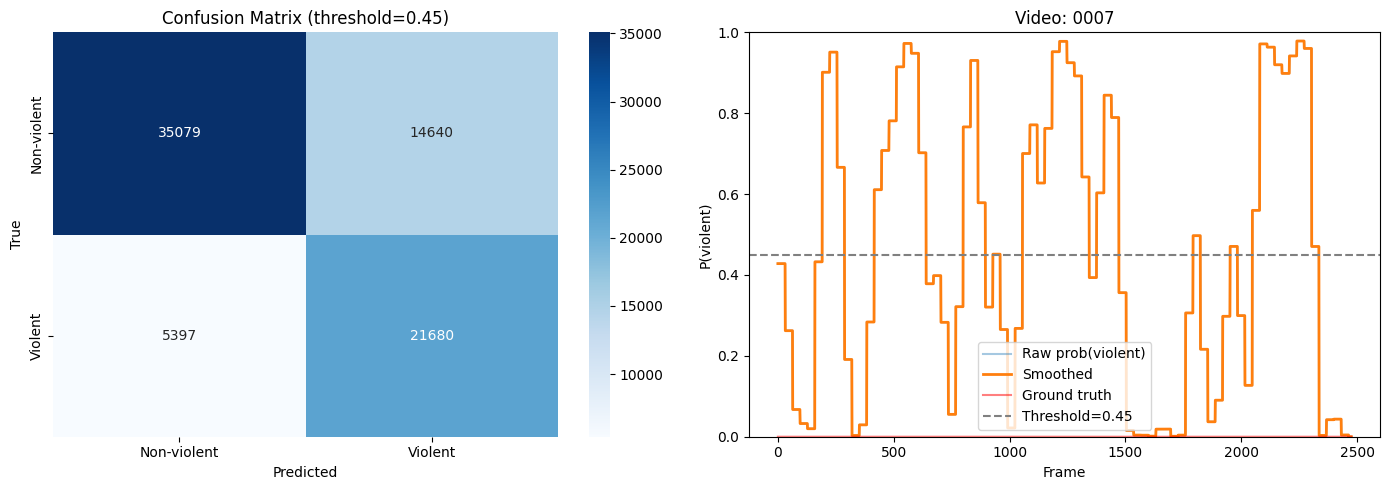


Classification Report:
              precision    recall  f1-score   support

 Non-violent       0.87      0.71      0.78     49719
     Violent       0.60      0.80      0.68     27077

    accuracy                           0.74     76796
   macro avg       0.73      0.75      0.73     76796
weighted avg       0.77      0.74      0.74     76796



In [ ]:
import matplotlib.pyplot as plt
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns

# Confusion matrix
_, all_preds_final, all_labels_final = predict_all_frames(
    val_data, models_weights, threshold=best_thr)

cm = confusion_matrix(all_labels_final, all_preds_final)
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Non-violent','Violent'],
            yticklabels=['Non-violent','Violent'], ax=axes[0])
axes[0].set_title(f'Confusion Matrix (threshold={best_thr:.2f})')
axes[0].set_ylabel('True')
axes[0].set_xlabel('Predicted')

sample = val_data[0]
N      = len(sample['labels'])
true_l = sample['labels']

parts = [sample['vis_feat'], sample['vis_scores']]
if 'global_feat' in sample and np.any(sample['global_feat'] != 0):
    parts.append(sample['global_feat'])
vis_f = np.concatenate(parts, axis=1)

aud_f = sample['aud_feat']
txt_f = sample['txt_feat']

# Быстрый forward через fusion_mdl без скользящего окна
agg_p = np.zeros((N,2), np.float64)
for s in range(0, max(1, N-WINDOW_SIZE+1), HOP_SIZE):
    e = min(s+WINDOW_SIZE, N); pad = WINDOW_SIZE-(e-s)
    v=vis_f[s:e]; a=aud_f[s:e]; t=txt_f[s:e]
    if pad:
        v=np.vstack([v,np.zeros((pad,v.shape[1]))])
        a=np.vstack([a,np.zeros((pad,a.shape[1]))])
        t=np.vstack([t,np.zeros((pad,t.shape[1]))])
    with torch.no_grad():
        pr = F.softmax(
            fusion_mdl(torch.from_numpy(v).unsqueeze(0).to(DEVICE),
                       torch.from_numpy(a).unsqueeze(0).to(DEVICE),
                       torch.from_numpy(t).unsqueeze(0).to(DEVICE)),1
        ).cpu().numpy()[0]
    for fi in range(s, e): agg_p[fi] += pr

agg_p /= np.maximum(agg_p.sum(1, keepdims=True), 1e-9)
p1_raw    = agg_p[:,1]
p1_smooth = medfilt(p1_raw.astype(np.float32), kernel_size=SMOOTH_KERNEL)

axes[1].plot(p1_raw,    alpha=0.4, label='Raw prob(violent)')
axes[1].plot(p1_smooth, linewidth=2, label='Smoothed')
axes[1].step(range(N), true_l, where='mid', color='red',
              alpha=0.5, label='Ground truth')
axes[1].axhline(best_thr, ls='--', color='gray', label=f'Threshold={best_thr:.2f}')
axes[1].set_title(f"Video: {sample['video_id']}")
axes[1].set_xlabel('Frame'); axes[1].set_ylabel('P(violent)')
axes[1].legend(); axes[1].set_ylim(0, 1)

plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, 'results.png'), dpi=120, bbox_inches='tight')
plt.show()

print("\nClassification Report:")
print(classification_report(all_labels_final, all_preds_final,
                             target_names=['Non-violent','Violent']))


Сравнение backbone-моделей

In [22]:
!pip install -q timm

In [18]:
# Импорты и конфигурация backbone-моделей
import os
import gc
import cv2
import timm
import torch
import torch.nn as nn
import torch.nn.functional as F
import numpy as np
import pandas as pd
import torchvision.transforms as T

from pathlib import Path
from tqdm.auto import tqdm
from torch.utils.data import Dataset, DataLoader, WeightedRandomSampler

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"

# Конфигурация backbone-моделей
BACKBONE_CONFIGS = {
    "resnet50": {
        "timm_name": "resnet50",
        "feat_dim": 2048,
    },
    "convnext_tiny": {
        "timm_name": "convnext_tiny",
        "feat_dim": 768,
    },
    "swin_tiny": {
        "timm_name": "swin_tiny_patch4_window7_224",
        "feat_dim": 768,
    },
    "efficientnet_b0": {
        "timm_name": "efficientnet_b0",
        "feat_dim": 1280,
    },
}

# Настройки извлечения признаков
BC_IMG_SIZE      = 224
BC_GLOBAL_STRIDE = 16
BC_GLOBAL_BATCH  = 32

# Настройки датасета
BC_WINDOW_SIZE = 64
BC_HOP_SIZE    = 32
BC_BATCH_SIZE  = 256

# Размерности существующих модальностей
BC_AUD_DIM = 1024
BC_TXT_DIM = 768
BC_BASE_VIS_DIM = 522   # vis_feat + vis_scores = 512 + 10

# Кэш backbone-моделей
_BC_MODELS = {}

# Трансформации для изображений
BC_TRANSFORM = T.Compose([
    T.ToPILImage(),
    T.Resize((BC_IMG_SIZE, BC_IMG_SIZE)),
    T.ToTensor(),
    T.Normalize(
        mean=[0.485, 0.456, 0.406],
        std =[0.229, 0.224, 0.225]
    )
])

print("Backbone comparison config initialized.")
print("DEVICE:", DEVICE)

Backbone comparison config initialized.
DEVICE: cuda


In [17]:
# Функции для загрузки и извлечения признаков backbone-моделей

def bc_get_backbone_model(backbone_key):
    if backbone_key in _BC_MODELS:
        return _BC_MODELS[backbone_key]

    cfg = BACKBONE_CONFIGS[backbone_key]
    model = timm.create_model(
        cfg["timm_name"],
        pretrained=True,
        num_classes=0,
        global_pool="avg"
    ).to(DEVICE)
    model.eval()

    _BC_MODELS[backbone_key] = model
    print(f"✓ Loaded backbone: {backbone_key} | feat_dim={cfg['feat_dim']}")
    return model


def bc_extract_backbone_features(video_path, ann_df, backbone_key, save_dtype=np.float16):
    """
    Потоковое извлечение глобальных visual features.
    Не хранит все raw frames в памяти.
    Подходит для resnet50 / convnext_tiny / swin_tiny / efficientnet_b0.
    """
    model = bc_get_backbone_model(backbone_key)
    feat_dim = BACKBONE_CONFIGS[backbone_key]["feat_dim"]

    N = len(ann_df)
    all_fids = np.array(sorted(ann_df["frame"].tolist()), dtype=np.int32)

    stride_fids = all_fids[::BC_GLOBAL_STRIDE]
    if all_fids[-1] not in stride_fids:
        stride_fids = np.append(stride_fids, all_fids[-1])
    stride_fids = np.unique(stride_fids)

    cap = cv2.VideoCapture(video_path)
    if not cap.isOpened():
        return np.zeros((N, feat_dim), dtype=save_dtype)

    feat_dict = {}
    batch_imgs = []
    batch_fids = []

    with torch.no_grad():
        for fid in stride_fids:
            cap.set(cv2.CAP_PROP_POS_FRAMES, int(fid))
            ret, frame = cap.read()
            if not ret or frame is None:
                continue

            rgb = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)
            img = BC_TRANSFORM(rgb)

            batch_imgs.append(img)
            batch_fids.append(int(fid))

            if len(batch_imgs) == BC_GLOBAL_BATCH:
                batch_tensor = torch.stack(batch_imgs).to(DEVICE, non_blocking=True)
                feats = model(batch_tensor).detach().cpu().numpy().astype(save_dtype)

                for j, f in enumerate(batch_fids):
                    feat_dict[f] = feats[j]

                batch_imgs = []
                batch_fids = []

                del batch_tensor, feats
                gc.collect()
                if torch.cuda.is_available():
                    torch.cuda.empty_cache()

        # добиваем хвост
        if len(batch_imgs) > 0:
            batch_tensor = torch.stack(batch_imgs).to(DEVICE, non_blocking=True)
            feats = model(batch_tensor).detach().cpu().numpy().astype(save_dtype)

            for j, f in enumerate(batch_fids):
                feat_dict[f] = feats[j]

            del batch_tensor, feats
            gc.collect()
            if torch.cuda.is_available():
                torch.cuda.empty_cache()

    cap.release()

    full_feat = np.zeros((N, feat_dim), dtype=save_dtype)

    if not feat_dict:
        return full_feat

    processed = np.array(sorted(feat_dict.keys()), dtype=np.int32)

    # быстрое сопоставление каждого кадра с ближайшим обработанным
    idxs = np.searchsorted(processed, all_fids)

    for i, fid in enumerate(all_fids):
        pos = idxs[i]

        if pos == 0:
            closest = processed[0]
        elif pos == len(processed):
            closest = processed[-1]
        else:
            left = processed[pos - 1]
            right = processed[pos]
            closest = left if abs(fid - left) <= abs(right - fid) else right

        full_feat[i] = feat_dict[int(closest)]

    return full_feat

In [32]:
# Кэширование backbone-признаков в уже существующие .npz
def bc_add_backbone_features_to_cache(split, backbone_key):
    feat_name = f"global_feat_{backbone_key}"
    pairs = get_video_list(split)

    for vp, ap in tqdm(pairs, desc=f"{backbone_key} [{split}]"):
        vid = Path(vp).stem
        cache_path = os.path.join(FEAT_DIR, f"{split}_{vid}.npz")

        if not os.path.exists(cache_path):
            continue

        d = dict(np.load(cache_path, allow_pickle=True))

        # Уже посчитано
        if feat_name in d and np.any(d[feat_name] != 0):
            continue

        ann = load_annotations(ap)

        try:
            gf = bc_extract_backbone_features(vp, ann, backbone_key=backbone_key)
        except Exception as e:
            print(f"⚠ {vid} | {backbone_key}: {e}")
            gf = np.zeros((len(ann), BACKBONE_CONFIGS[backbone_key]["feat_dim"]), np.float32)

        d[feat_name] = gf
        np.savez_compressed(cache_path, **d)
        gc.collect()

    print(f"[{split}] backbone {backbone_key} cached.")


for bk in ["resnet50", "convnext_tiny", "swin_tiny", "efficientnet_b0"]:
    bc_add_backbone_features_to_cache("Training", bk)
    bc_add_backbone_features_to_cache("Validation", bk)

# Перезагрузка train_data / val_data из обновленных кэшей
train_data_bc, val_data_bc = [], []

for split, storage in [("Training", train_data_bc), ("Validation", val_data_bc)]:
    for vp, ap in get_video_list(split):
        vid = Path(vp).stem
        cache_path = os.path.join(FEAT_DIR, f"{split}_{vid}.npz")
        if os.path.exists(cache_path):
            storage.append(dict(np.load(cache_path, allow_pickle=True)))

print(f"Перезагруженный кэш для сравнения основных компонентов: train={len(train_data_bc)} | val={len(val_data_bc)}")

resnet50 [Training]:  36%|███▋      | 37/102 [00:10<00:18,  3.52it/s]

✓ Loaded backbone: resnet50 | feat_dim=2048


resnet50 [Training]: 100%|██████████| 102/102 [00:43<00:00,  2.34it/s]


[Training] backbone resnet50 cached.


resnet50 [Validation]: 100%|██████████| 17/17 [00:03<00:00,  4.64it/s]


...

✓ Loaded backbone: efficientnet_b0 | feat_dim=1280


efficientnet_b0 [Training]: 100%|██████████| 102/102 [02:40<00:00,  1.57s/it]


[Training] backbone efficientnet_b0 cached.


efficientnet_b0 [Validation]: 100%|██████████| 17/17 [00:13<00:00,  1.27it/s]


[Validation] backbone efficientnet_b0 cached.
Перезагруженный кэш для сравнения основных компонентов: train=102 | val=17


In [16]:
# Отдельный Dataset под backbone-сравнение

class BC_ViolenceDataset(Dataset):
    def __init__(
        self,
        all_data,
        backbone_key=None,
        window=BC_WINDOW_SIZE,
        hop=BC_HOP_SIZE,
        modal_p=0.0,
        use_aux_visual=True
    ):
        self.samples = []
        self.modal_p = modal_p
        self.backbone_key = backbone_key
        self.use_aux_visual = use_aux_visual

        extra_dim = 0 if backbone_key is None else BACKBONE_CONFIGS[backbone_key]["feat_dim"]

        if use_aux_visual:
            self.vis_dim = BC_BASE_VIS_DIM + extra_dim
        else:
            self.vis_dim = extra_dim

        for d in all_data:
            parts = []

            # дополнительные визуальные признаки (vis_feat + vis_scores)
            if use_aux_visual:
                parts.append(d["vis_feat"])
                parts.append(d["vis_scores"])

            # backbone-признаки сцены
            if backbone_key is not None:
                feat_name = f"global_feat_{backbone_key}"
                if feat_name in d:
                    parts.append(d[feat_name])
                else:
                    parts.append(np.zeros((len(d["labels"]), extra_dim), np.float32))

            vis = np.concatenate(parts, axis=1)

            aud = d["aud_feat"]
            txt = d["txt_feat"]
            lbl = d["labels"]
            N = len(lbl)

            for s in range(0, max(1, N - window + 1), hop):
                e = min(s + window, N)
                pad = window - (e - s)

                v = vis[s:e]
                a = aud[s:e]
                t = txt[s:e]

                if pad:
                    v = np.vstack([v, np.zeros((pad, v.shape[1]), np.float32)])
                    a = np.vstack([a, np.zeros((pad, a.shape[1]), np.float32)])
                    t = np.vstack([t, np.zeros((pad, t.shape[1]), np.float32)])

                center_label = int(lbl[min(s + window // 2, N - 1)])

                self.samples.append((
                    v.astype(np.float32),
                    a.astype(np.float32),
                    t.astype(np.float32),
                    center_label
                ))

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):
        v, a, t, y = self.samples[idx]

        # modal dropout только для аудио и текста
        if self.modal_p > 0:
            if np.random.rand() < self.modal_p:
                a = np.zeros_like(a)
            if np.random.rand() < self.modal_p:
                t = np.zeros_like(t)

        return (
            torch.tensor(v, dtype=torch.float32),
            torch.tensor(a, dtype=torch.float32),
            torch.tensor(t, dtype=torch.float32),
            torch.tensor(y, dtype=torch.long)
        )


def bc_make_loaders(backbone_key=None, modal_p=0.0, use_aux_visual=True):
    train_ds = BC_ViolenceDataset(
        train_data_bc,
        backbone_key=backbone_key,
        modal_p=modal_p,
        use_aux_visual=use_aux_visual
    )
    val_ds = BC_ViolenceDataset(
        val_data_bc,
        backbone_key=backbone_key,
        modal_p=0.0,
        use_aux_visual=use_aux_visual
    )

    y_train = np.array([y for _, _, _, y in train_ds.samples])
    class_counts = np.bincount(y_train)
    class_weights = 1.0 / np.maximum(class_counts, 1)
    sample_weights = class_weights[y_train]

    sampler = WeightedRandomSampler(
        weights=torch.tensor(sample_weights, dtype=torch.double),
        num_samples=len(sample_weights),
        replacement=True
    )

    train_loader = DataLoader(
        train_ds,
        batch_size=BC_BATCH_SIZE,
        sampler=sampler,
        num_workers=2,
        pin_memory=True
    )
    val_loader = DataLoader(
        val_ds,
        batch_size=BC_BATCH_SIZE,
        shuffle=False,
        num_workers=2,
        pin_memory=True
    )

    print(
        f"Backbone={backbone_key} | VIS_DIM={train_ds.vis_dim} | "
        f"use_aux_visual={use_aux_visual}"
    )
    print(f"Train samples={len(train_ds)} | Val samples={len(val_ds)}")

    return train_ds, val_ds, train_loader, val_loader

In [19]:
# Отдельные модели для сравнения backbone-моделей и мультимодальных экспериментов

class BC_ModalMLP(nn.Module):
    """
    Универсальная MLP-голова для одномодальных baseline-моделей
    Используется для visual-only, audio-only и text-only экспериментов
    """
    def __init__(self, in_dim, hidden=256, dropout=0.3):
        super().__init__()
        self.net = nn.Sequential(
            nn.LayerNorm(in_dim),
            nn.Linear(in_dim, hidden),
            nn.GELU(),
            nn.Dropout(dropout),
            nn.Linear(hidden, 2)
        )

    def forward(self, x):
        # Агрегация по времени внутри окна
        return self.net(x.mean(1))


class BC_VisModel(nn.Module):
    """
    Visual-only модель
    """
    def __init__(self, vis_dim):
        super().__init__()
        self.mlp = BC_ModalMLP(vis_dim)

    def forward(self, v, a, t):
        return self.mlp(v)


class BC_AudModel(nn.Module):
    """
    Audio-only baseline
    """
    def __init__(self):
        super().__init__()
        self.mlp = BC_ModalMLP(BC_AUD_DIM)

    def forward(self, v, a, t):
        return self.mlp(a)


class BC_TxtModel(nn.Module):
    """
    Text-only baseline
    """
    def __init__(self):
        super().__init__()
        self.mlp = BC_ModalMLP(BC_TXT_DIM)

    def forward(self, v, a, t):
        return self.mlp(t)

class BC_CrossModalFusion(nn.Module):
    """
    Мультимодальная модель fusion
    Используется для сравнения top-2 backbone-моделей
    """
    def __init__(
        self,
        vis_dim,
        aud_dim=BC_AUD_DIM,
        txt_dim=BC_TXT_DIM,
        P=256,
        heads=4,
        layers=2,
        drop=0.3
    ):
        super().__init__()

        # Проекции в общее пространство
        self.vp = nn.Sequential(
            nn.LayerNorm(vis_dim),
            nn.Linear(vis_dim, P)
        )
        self.ap = nn.Sequential(
            nn.LayerNorm(aud_dim),
            nn.Linear(aud_dim, P)
        )
        self.tp = nn.Sequential(
            nn.LayerNorm(txt_dim),
            nn.Linear(txt_dim, P)
        )

        # Независимые энкодеры по модальностям
        enc_v = nn.TransformerEncoderLayer(
            d_model=P, nhead=heads, dropout=drop, batch_first=True
        )
        enc_a = nn.TransformerEncoderLayer(
            d_model=P, nhead=heads, dropout=drop, batch_first=True
        )
        enc_t = nn.TransformerEncoderLayer(
            d_model=P, nhead=heads, dropout=drop, batch_first=True
        )

        self.ve = nn.TransformerEncoder(enc_v, num_layers=layers)
        self.ae = nn.TransformerEncoder(enc_a, num_layers=layers)
        self.te = nn.TransformerEncoder(enc_t, num_layers=layers)

        # Cross-modal attention: audio/text -> video
        self.attn_av = nn.MultiheadAttention(
            embed_dim=P, num_heads=heads, dropout=drop, batch_first=True
        )
        self.attn_tv = nn.MultiheadAttention(
            embed_dim=P, num_heads=heads, dropout=drop, batch_first=True
        )

        # Классификатор
        self.cls = nn.Sequential(
            nn.LayerNorm(P * 3),
            nn.Linear(P * 3, 256),
            nn.GELU(),
            nn.Dropout(drop),
            nn.Linear(256, 2)
        )

    def forward(self, v, a, t):
        # Проекция + внутримодальное кодирование
        v = self.ve(self.vp(v))
        a = self.ae(self.ap(a))
        t = self.te(self.tp(t))

        # Межмодальное согласование с визуальным контекстом
        a2, _ = self.attn_av(a, v, v)   # audio attends to video
        t2, _ = self.attn_tv(t, v, v)   # text attends to video

        # Агрегация по времени
        v = v.mean(1)
        a = a2.mean(1)
        t = t2.mean(1)

        # Объединение модальностей и классификация
        x = torch.cat([v, a, t], dim=1)
        return self.cls(x)

In [31]:
# Этап 1: visual-only сравнение backbone-моделей

backbone_results = {}

for bk in ["resnet50", "convnext_tiny", "swin_tiny", "efficientnet_b0"]:
    print("\n" + "=" * 80)
    print(f"STAGE 1 — Visual-only backbone comparison | {bk}")

    train_ds_bk, val_ds_bk, train_loader_bk, val_loader_bk = bc_make_loaders(
        backbone_key=bk,
        modal_p=0.0,
        use_aux_visual=False
    )

    vis_model_bk = BC_VisModel(vis_dim=train_ds_bk.vis_dim)

    vis_model_bk, f1_bk = train_model(
        vis_model_bk,
        train_loader_bk,
        val_loader_bk,
        epochs=EPOCHS,
        ckpt_path=os.path.join(CKPT_DIR, f"bc_vis_{bk}_best.pt"),
        patience=10
    )

    backbone_results[bk] = {
        "vis_dim": train_ds_bk.vis_dim,
        "f1": f1_bk
    }

print("\n" + "=" * 80)
print("Visual-only backbone results:")
for bk, res in backbone_results.items():
    print(f"{bk:20s} | VIS_DIM = {res['vis_dim']:4d} | F1 = {res['f1']:.4f}")


STAGE 1 — Visual-only backbone comparison | resnet50
Backbone=resnet50 | VIS_DIM=2048 | use_aux_visual=False
Train samples=23940 | Val samples=2376
Epoch   1/40 | Loss 0.0503 | Val F1 0.6953 ✓ best
Epoch   2/40 | Loss 0.0354 | Val F1 0.6983 ✓ best
Epoch   3/40 | Loss 0.0292 | Val F1 0.6924
Epoch   4/40 | Loss 0.0255 | Val F1 0.6567
Epoch   5/40 | Loss 0.0235 | Val F1 0.6963
Epoch   6/40 | Loss 0.0211 | Val F1 0.6856
Epoch   7/40 | Loss 0.0192 | Val F1 0.6418
Epoch   8/40 | Loss 0.0176 | Val F1 0.6276
Epoch   9/40 | Loss 0.0167 | Val F1 0.6811
Epoch  10/40 | Loss 0.0157 | Val F1 0.6739
Epoch  11/40 | Loss 0.0149 | Val F1 0.6669
Epoch  12/40 | Loss 0.0139 | Val F1 0.6603
  Early stopping (epoch 12)
  Лучший Val F1: 0.6983

STAGE 1 — Visual-only backbone comparison | convnext_tiny
Backbone=convnext_tiny | VIS_DIM=768 | use_aux_visual=False
Train samples=23940 | Val samples=2376
Epoch   1/40 | Loss 0.0498 | Val F1 0.6871 ✓ best
Epoch   2/40 | Loss 0.0376 | Val F1 0.7299 ✓ best
Epoch   3/4

In [32]:
# Выбор двух лучших backbone-моделей по результатам этапа 1

backbone_results_df = pd.DataFrame([
    {
        "backbone": bk,
        "vis_dim": res["vis_dim"],
        "macro_f1": res["f1"]
    }
    for bk, res in backbone_results.items()
]).sort_values(by="macro_f1", ascending=False).reset_index(drop=True)

display(backbone_results_df)

top2_backbones = backbone_results_df["backbone"].tolist()[:2]
best_backbone = top2_backbones[0]

print(f"\nЛучшая backbone-модель по результатам этапа 1: {best_backbone}")
print(f"Top-2 backbone-модели для этапа 2: {top2_backbones}")

,backbone,vis_dim,macro_f1
0,convnext_tiny,768,0.730357
1,resnet50,2048,0.698287
2,swin_tiny,768,0.669061
3,efficientnet_b0,1280,0.472644



Лучшая backbone-модель по результатам этапа 1: convnext_tiny
Top-2 backbone-модели для этапа 2: ['convnext_tiny', 'resnet50']


In [33]:
# Этап 2: сравнение top-2 backbone-моделей в составе мультимодальной архитектуры

multimodal_backbone_results = {}

for bk in top2_backbones:
    print("\n" + "=" * 80)
    print(f"STAGE 2 — Multimodal backbone comparison | {bk}")

    train_ds_bk, val_ds_bk, train_loader_bk, val_loader_bk = bc_make_loaders(
        backbone_key=bk,
        modal_p=MODAL_DROPOUT_P,
        use_aux_visual=True   # здесь уже используем полное visual-представление
    )

    fusion_model_bk, f1_fusion_bk = train_model(
        BC_CrossModalFusion(vis_dim=train_ds_bk.vis_dim),
        train_loader_bk,
        val_loader_bk,
        epochs=EPOCHS,
        ckpt_path=os.path.join(CKPT_DIR, f"bc_fusion_{bk}_best.pt"),
        patience=10
    )

    multimodal_backbone_results[bk] = {
        "vis_dim": train_ds_bk.vis_dim,
        "f1": f1_fusion_bk
    }

print("\n" + "=" * 80)
print("Multimodal backbone results:")
for bk, res in multimodal_backbone_results.items():
    print(f"{bk:20s} | VIS_DIM = {res['vis_dim']:4d} | F1 = {res['f1']:.4f}")


STAGE 2 — Multimodal backbone comparison | convnext_tiny
Backbone=convnext_tiny | VIS_DIM=1290 | use_aux_visual=True
Train samples=23940 | Val samples=2376
Epoch   1/40 | Loss 0.0414 | Val F1 0.6963 ✓ best
Epoch   2/40 | Loss 0.0259 | Val F1 0.6999 ✓ best
Epoch   3/40 | Loss 0.0196 | Val F1 0.7103 ✓ best
Epoch   4/40 | Loss 0.0154 | Val F1 0.7071
Epoch   5/40 | Loss 0.0132 | Val F1 0.7090
Epoch   6/40 | Loss 0.0112 | Val F1 0.7216 ✓ best
Epoch   7/40 | Loss 0.0096 | Val F1 0.7081
Epoch   8/40 | Loss 0.0079 | Val F1 0.7114
Epoch   9/40 | Loss 0.0068 | Val F1 0.6714
Epoch  10/40 | Loss 0.0067 | Val F1 0.7158
Epoch  11/40 | Loss 0.0058 | Val F1 0.7046
Epoch  12/40 | Loss 0.0050 | Val F1 0.7026
Epoch  13/40 | Loss 0.0044 | Val F1 0.6952
Epoch  14/40 | Loss 0.0035 | Val F1 0.6796
Epoch  15/40 | Loss 0.0037 | Val F1 0.6954
Epoch  16/40 | Loss 0.0037 | Val F1 0.7101
  Early stopping (epoch 16)
  Лучший Val F1: 0.7216

STAGE 2 — Multimodal backbone comparison | resnet50
Backbone=resnet50 | VI

In [34]:
multimodal_backbone_results_df = pd.DataFrame([
    {
        "backbone": bk,
        "vis_dim": res["vis_dim"],
        "macro_f1": res["f1"]
    }
    for bk, res in multimodal_backbone_results.items()
]).sort_values(by="macro_f1", ascending=False).reset_index(drop=True)

display(multimodal_backbone_results_df)

final_backbone = multimodal_backbone_results_df.loc[0, "backbone"]
print(f"\nИтоговая backbone-модель по результатам этапа 2: {final_backbone}")

,backbone,vis_dim,macro_f1
0,convnext_tiny,1290,0.721628
1,resnet50,2570,0.701062



Итоговая backbone-модель по результатам этапа 2: convnext_tiny


In [37]:
# Этап 3: сравнение итоговой модели с baseline и одномодальными решениями

print("\n" + "=" * 80)
print(f"STAGE 3 — Final comparison with selected backbone: {final_backbone}")

train_ds_final, val_ds_final, train_loader_final, val_loader_final = bc_make_loaders(
    backbone_key=final_backbone,
    modal_p=MODAL_DROPOUT_P,
    use_aux_visual=True
)

final_vis_dim = train_ds_final.vis_dim

# Итоговая мультимодальная модель
fusion_model_final, f1_fusion_final = train_model(
    BC_CrossModalFusion(vis_dim=final_vis_dim),
    train_loader_final,
    val_loader_final,
    epochs=EPOCHS,
    ckpt_path=os.path.join(CKPT_DIR, f"final_fusion_{final_backbone}.pt"),
    patience=10
)

# Visual-only baseline с итоговым backbone
vis_model_final, f1_vis_final = train_model(
    BC_VisModel(vis_dim=final_vis_dim),
    train_loader_final,
    val_loader_final,
    epochs=EPOCHS,
    ckpt_path=os.path.join(CKPT_DIR, f"final_vis_{final_backbone}.pt"),
    patience=10
)

# Audio-only
aud_model_final, f1_aud_final = train_model(
    BC_AudModel(),
    train_loader_final,
    val_loader_final,
    epochs=EPOCHS,
    ckpt_path=os.path.join(CKPT_DIR, "final_aud.pt"),
    patience=10
)

# Text-only
txt_model_final, f1_txt_final = train_model(
    BC_TxtModel(),
    train_loader_final,
    val_loader_final,
    epochs=EPOCHS,
    ckpt_path=os.path.join(CKPT_DIR, "final_txt.pt"),
    patience=10
)

print("\n" + "=" * 80)
print("Final stage results:")
print(f"Fusion ({final_backbone})   : {f1_fusion_final:.4f}")
print(f"Visual ({final_backbone})   : {f1_vis_final:.4f}")
print(f"Audio only                  : {f1_aud_final:.4f}")
print(f"Text only                   : {f1_txt_final:.4f}")
print(f"Competition baseline        : 0.7300")


STAGE 3 — Final comparison with selected backbone: convnext_tiny
Backbone=convnext_tiny | VIS_DIM=1290 | use_aux_visual=True
Train samples=23940 | Val samples=2376
Epoch   1/40 | Loss 0.0420 | Val F1 0.6887 ✓ best
Epoch   2/40 | Loss 0.0274 | Val F1 0.7393 ✓ best
Epoch   3/40 | Loss 0.0207 | Val F1 0.6846
Epoch   4/40 | Loss 0.0162 | Val F1 0.6920
Epoch   5/40 | Loss 0.0130 | Val F1 0.6973
Epoch   6/40 | Loss 0.0113 | Val F1 0.6801
Epoch   7/40 | Loss 0.0097 | Val F1 0.7064
Epoch   8/40 | Loss 0.0081 | Val F1 0.7111
Epoch   9/40 | Loss 0.0079 | Val F1 0.6610
Epoch  10/40 | Loss 0.0059 | Val F1 0.6796
Epoch  11/40 | Loss 0.0060 | Val F1 0.6981
Epoch  12/40 | Loss 0.0049 | Val F1 0.6913
  Early stopping (epoch 12)
  Лучший Val F1: 0.7393
Epoch   1/40 | Loss 0.0504 | Val F1 0.6612 ✓ best
Epoch   2/40 | Loss 0.0365 | Val F1 0.6647 ✓ best
Epoch   3/40 | Loss 0.0314 | Val F1 0.7069 ✓ best
Epoch   4/40 | Loss 0.0276 | Val F1 0.7134 ✓ best
Epoch   5/40 | Loss 0.0251 | Val F1 0.7120
Epoch   6/

In [38]:
final_comparison_rows = [
    {
        "model": "CrossModalFusion",
        "backbone": final_backbone,
        "modalities": "video + audio + text",
        "macro_f1": round(float(f1_fusion_final), 4)
    },
    {
        "model": "Visual-only",
        "backbone": final_backbone,
        "modalities": "video",
        "macro_f1": round(float(f1_vis_final), 4)
    },
    {
        "model": "Audio-only",
        "backbone": "-",
        "modalities": "audio",
        "macro_f1": round(float(f1_aud_final), 4)
    },
    {
        "model": "Text-only",
        "backbone": "-",
        "modalities": "text",
        "macro_f1": round(float(f1_txt_final), 4)
    },
    {
        "model": "Competition baseline",
        "backbone": "ResNet-50",
        "modalities": "video",
        "macro_f1": 0.7300
    }
]

final_comparison_df = pd.DataFrame(final_comparison_rows).sort_values(
    by="macro_f1", ascending=False
).reset_index(drop=True)

display(final_comparison_df)
final_comparison_df.to_csv(os.path.join(CKPT_DIR, "final_model_comparison.csv"), index=False)

,model,backbone,modalities,macro_f1
0,CrossModalFusion,convnext_tiny,video + audio + text,0.7393
1,Competition baseline,ResNet-50,video,0.7300
2,Visual-only,convnext_tiny,video,0.7234
3,Audio-only,-,audio,0.3688
4,Text-only,-,text,0.3565


АБЛЯЦИОННОЕ ИССЛЕДОВАНИЕ

*   full multimodal
*   without audio
*   without text
*   without affective features
*   without modal dropout




In [13]:
class AblationDataset(Dataset):
    def __init__(
        self,
        all_data,
        backbone_key,
        window=BC_WINDOW_SIZE,
        hop=BC_HOP_SIZE,
        modal_p=0.0,
        use_audio=True,
        use_text=True,
        use_affective=True
    ):
        self.samples = []
        self.modal_p = modal_p
        self.backbone_key = backbone_key
        self.use_audio = use_audio
        self.use_text = use_text
        self.use_affective = use_affective

        backbone_dim = BACKBONE_CONFIGS[backbone_key]["feat_dim"]

        # visual dim:
        # либо backbone + affective features,
        # либо только backbone
        if use_affective:
            self.vis_dim = BC_BASE_VIS_DIM + backbone_dim
        else:
            self.vis_dim = backbone_dim

        for d in all_data:
            vis_parts = []

            # дополнительные аффективные признаки
            if use_affective:
                vis_parts.append(d["vis_feat"])
                vis_parts.append(d["vis_scores"])

            # backbone-признаки сцены
            feat_name = f"global_feat_{backbone_key}"
            if feat_name in d:
                vis_parts.append(d[feat_name])
            else:
                vis_parts.append(np.zeros((len(d["labels"]), backbone_dim), np.float32))

            vis = np.concatenate(vis_parts, axis=1)

            # аудио
            if use_audio:
                aud = d["aud_feat"]
            else:
                aud = np.zeros((len(d["labels"]), BC_AUD_DIM), np.float32)

            # текст
            if use_text:
                txt = d["txt_feat"]
            else:
                txt = np.zeros((len(d["labels"]), BC_TXT_DIM), np.float32)

            lbl = d["labels"]
            N = len(lbl)

            for s in range(0, max(1, N - window + 1), hop):
                e = min(s + window, N)
                pad = window - (e - s)

                v = vis[s:e]
                a = aud[s:e]
                t = txt[s:e]

                if pad:
                    v = np.vstack([v, np.zeros((pad, v.shape[1]), np.float32)])
                    a = np.vstack([a, np.zeros((pad, a.shape[1]), np.float32)])
                    t = np.vstack([t, np.zeros((pad, t.shape[1]), np.float32)])

                center_label = int(lbl[min(s + window // 2, N - 1)])

                self.samples.append((
                    v.astype(np.float32),
                    a.astype(np.float32),
                    t.astype(np.float32),
                    center_label
                ))

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):
        v, a, t, y = self.samples[idx]

        # modal dropout применяем только к тем модальностям, которые включены
        if self.modal_p > 0:
            if self.use_audio and np.random.rand() < self.modal_p:
                a = np.zeros_like(a)
            if self.use_text and np.random.rand() < self.modal_p:
                t = np.zeros_like(t)

        return (
            torch.tensor(v, dtype=torch.float32),
            torch.tensor(a, dtype=torch.float32),
            torch.tensor(t, dtype=torch.float32),
            torch.tensor(y, dtype=torch.long)
        )


def make_ablation_loaders(
    backbone_key,
    modal_p=0.0,
    use_audio=True,
    use_text=True,
    use_affective=True
):
    train_ds = AblationDataset(
        train_data_bc,
        backbone_key=backbone_key,
        modal_p=modal_p,
        use_audio=use_audio,
        use_text=use_text,
        use_affective=use_affective
    )

    val_ds = AblationDataset(
        val_data_bc,
        backbone_key=backbone_key,
        modal_p=0.0,
        use_audio=use_audio,
        use_text=use_text,
        use_affective=use_affective
    )

    y_train = np.array([y for _, _, _, y in train_ds.samples])
    class_counts = np.bincount(y_train)
    class_weights = 1.0 / np.maximum(class_counts, 1)
    sample_weights = class_weights[y_train]

    sampler = WeightedRandomSampler(
        weights=torch.tensor(sample_weights, dtype=torch.double),
        num_samples=len(sample_weights),
        replacement=True
    )

    train_loader = DataLoader(
        train_ds,
        batch_size=BC_BATCH_SIZE,
        sampler=sampler,
        num_workers=2,
        pin_memory=True
    )

    val_loader = DataLoader(
        val_ds,
        batch_size=BC_BATCH_SIZE,
        shuffle=False,
        num_workers=2,
        pin_memory=True
    )

    print(
        f"backbone={backbone_key} | VIS_DIM={train_ds.vis_dim} | "
        f"audio={use_audio} | text={use_text} | affective={use_affective} | modal_p={modal_p}"
    )

    return train_ds, val_ds, train_loader, val_loader

In [14]:
# Настройки абляции

print("Final backbone:", final_backbone)

ABL_EPOCHS = EPOCHS
ABL_PATIENCE = 8

ablation_settings = [
    {
        "name": "full multimodal",
        "use_audio": True,
        "use_text": True,
        "use_affective": True,
        "modal_p": MODAL_DROPOUT_P
    },
    {
        "name": "without audio",
        "use_audio": False,
        "use_text": True,
        "use_affective": True,
        "modal_p": MODAL_DROPOUT_P
    },
    {
        "name": "without text",
        "use_audio": True,
        "use_text": False,
        "use_affective": True,
        "modal_p": MODAL_DROPOUT_P
    },
    {
        "name": "without affective features",
        "use_audio": True,
        "use_text": True,
        "use_affective": False,
        "modal_p": MODAL_DROPOUT_P
    },
    {
        "name": "without modal dropout",
        "use_audio": True,
        "use_text": True,
        "use_affective": True,
        "modal_p": 0.0
    },
]

Final backbone: convnext_tiny


In [34]:
ablation_rows = []

for cfg in ablation_settings:
    print("\n" + "=" * 80)
    print(f"ABLATION: {cfg['name']}")

    train_ds_ab, val_ds_ab, train_loader_ab, val_loader_ab = make_ablation_loaders(
        backbone_key=final_backbone,
        modal_p=cfg["modal_p"],
        use_audio=cfg["use_audio"],
        use_text=cfg["use_text"],
        use_affective=cfg["use_affective"]
    )

    model_ab = BC_CrossModalFusion(vis_dim=train_ds_ab.vis_dim)

    model_ab, f1_ab = train_model(
        model_ab,
        train_loader_ab,
        val_loader_ab,
        epochs=ABL_EPOCHS,
        ckpt_path=os.path.join(
            CKPT_DIR,
            f"ablation_{cfg['name'].replace(' ', '_').replace('-', '_')}.pt"
        ),
        patience=ABL_PATIENCE
    )

    ablation_rows.append({
        "setting": cfg["name"],
        "backbone": final_backbone,
        "use_audio": cfg["use_audio"],
        "use_text": cfg["use_text"],
        "use_affective": cfg["use_affective"],
        "modal_dropout": cfg["modal_p"] > 0,
        "macro_f1": round(float(f1_ab), 4)
    })

    gc.collect()
    if torch.cuda.is_available():
        torch.cuda.empty_cache()


ABLATION: full multimodal
backbone=convnext_tiny | VIS_DIM=1290 | audio=True | text=True | affective=True | modal_p=0.2
Epoch   1/40 | Loss 0.0423 | Val F1 0.6783 ✓ best
Epoch   2/40 | Loss 0.0261 | Val F1 0.6769
Epoch   3/40 | Loss 0.0203 | Val F1 0.7344 ✓ best
Epoch   4/40 | Loss 0.0168 | Val F1 0.6810
Epoch   5/40 | Loss 0.0134 | Val F1 0.6964
Epoch   6/40 | Loss 0.0114 | Val F1 0.6499
Epoch   7/40 | Loss 0.0098 | Val F1 0.6629
Epoch   8/40 | Loss 0.0090 | Val F1 0.6571
Epoch   9/40 | Loss 0.0070 | Val F1 0.6931
Epoch  10/40 | Loss 0.0064 | Val F1 0.6417
Epoch  11/40 | Loss 0.0066 | Val F1 0.6575
  Early stopping (epoch 11)
  Лучший Val F1: 0.7344

ABLATION: without audio
backbone=convnext_tiny | VIS_DIM=1290 | audio=False | text=True | affective=True | modal_p=0.2
Epoch   1/40 | Loss 0.0408 | Val F1 0.6128 ✓ best
Epoch   2/40 | Loss 0.0260 | Val F1 0.6112
Epoch   3/40 | Loss 0.0200 | Val F1 0.6620 ✓ best
Epoch   4/40 | Loss 0.0161 | Val F1 0.6516
Epoch   5/40 | Loss 0.0132 | Val F

In [35]:
# Таблица результатов

ablation_df = pd.DataFrame(ablation_rows)
ablation_df = ablation_df.sort_values(by="macro_f1", ascending=False).reset_index(drop=True)

display(ablation_df)

ablation_df.to_csv(os.path.join(CKPT_DIR, "ablation_results.csv"), index=False)
print("Saved:", os.path.join(CKPT_DIR, "ablation_results.csv"))

,setting,backbone,use_audio,use_text,use_affective,modal_dropout,macro_f1
0,full multimodal,convnext_tiny,True,True,True,True,0.7344
1,without affective features,convnext_tiny,True,True,False,True,0.7344
2,without text,convnext_tiny,True,False,True,True,0.7271
3,without modal dropout,convnext_tiny,True,True,True,False,0.7222
4,without audio,convnext_tiny,False,True,True,True,0.6894


Saved: /content/drive/MyDrive/DVD_outputs/ablation_ckpts/ablation_results.csv


In [36]:
full_score = ablation_df.loc[ablation_df["setting"] == "full multimodal", "macro_f1"].values

if len(full_score) > 0:
    full_score = float(full_score[0])

    print("\n" + "=" * 80)
    print("КРАТКИЙ ВЫВОД ПО АБЛЯЦИИ")
    print("=" * 80)

    for _, row in ablation_df.iterrows():
        if row["setting"] == "full multimodal":
            print(f"{row['setting']}: {row['macro_f1']:.4f}  <-- базовая полная модель")
        else:
            delta = row["macro_f1"] - full_score
            print(f"{row['setting']}: {row['macro_f1']:.4f} | Δ={delta:+.4f}")


КРАТКИЙ ВЫВОД ПО АБЛЯЦИИ
full multimodal: 0.7344  <-- базовая полная модель
without affective features: 0.7344 | Δ=+0.0000
without text: 0.7271 | Δ=-0.0073
without modal dropout: 0.7222 | Δ=-0.0122
without audio: 0.6894 | Δ=-0.0450
